In [2]:
!pip install mp-api -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.1/126.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━

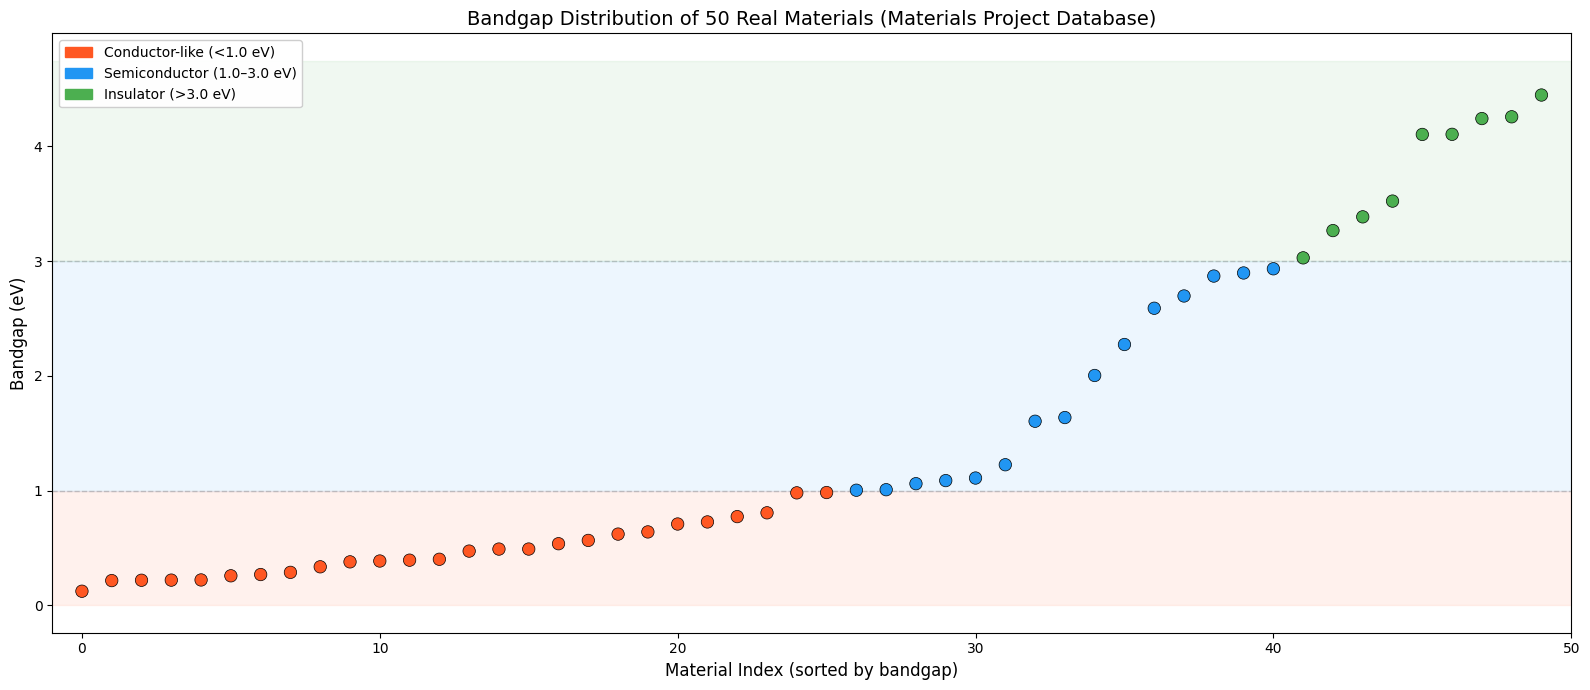

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

category_colors = {
    "Conductor-like": "#FF5722",
    "Semiconductor": "#2196F3",
    "Insulator": "#4CAF50"
}

df_sorted = df_real.sort_values("Bandgap_eV").reset_index(drop=True)
colors = [category_colors[c] for c in df_sorted["Category"]]

plt.figure(figsize=(16, 7))

# Shaded background zones instead of side text
plt.axhspan(0, 1.0, color="#FF5722", alpha=0.08, zorder=0)
plt.axhspan(1.0, 3.0, color="#2196F3", alpha=0.08, zorder=0)
plt.axhspan(3.0, df_sorted["Bandgap_eV"].max() + 0.3, color="#4CAF50", alpha=0.08, zorder=0)

plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.4, linewidth=1)
plt.axhline(y=3.0, color='gray', linestyle='--', alpha=0.4, linewidth=1)

plt.scatter(range(len(df_sorted)), df_sorted["Bandgap_eV"],
            c=colors, s=80, edgecolors='black', linewidth=0.5, zorder=3)

patches = [mpatches.Patch(color=c, label=f"{k} ({'<1.0' if k=='Conductor-like' else '1.0–3.0' if k=='Semiconductor' else '>3.0'} eV)")
           for k, c in category_colors.items()]
plt.legend(handles=patches, loc='upper left', fontsize=10, framealpha=0.95)

plt.title(f"Bandgap Distribution of {len(df_sorted)} Real Materials (Materials Project Database)", fontsize=14)
plt.xlabel("Material Index (sorted by bandgap)", fontsize=12)
plt.ylabel("Bandgap (eV)", fontsize=12)
plt.xlim(-1, len(df_sorted))
plt.tight_layout()
plt.savefig("real_materials_distribution.png", dpi=150)
plt.show()

from google.colab import files
files.download("real_materials_distribution.png")

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X = df_real2[["Bandgap_eV"]]
y = df_real2["Is_Metal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_metal2 = DecisionTreeClassifier(max_depth=3)
model_metal2.fit(X_train, y_train)

predictions = model_metal2.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Accuracy: {accuracy * 100:.1f}%")
print()
print(classification_report(y_test, predictions, zero_division=0))

Training samples: 64
Testing samples: 16
Accuracy: 100.0%

              precision    recall  f1-score   support

       False       1.00      1.00      1.00         1
        True       1.00      1.00      1.00        15

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



In [8]:
from mp_api.client import MPRester
import pandas as pd

API_KEY = "T8NM32mVsIRiBobfmd99WiWnIoByjVuX"  # your real key

with MPRester(API_KEY) as mpr:
    docs = mpr.materials.summary.search(
        band_gap=(0, 4.5),
        num_chunks=1,
        chunk_size=150,  # more materials this time
        fields=[
            "material_id", "formula_pretty", "band_gap", "is_metal",
            "density", "volume", "nsites", "energy_above_hull",
            "formation_energy_per_atom"
        ]
    )

data = []
for doc in docs:
    data.append({
        "Material_ID": doc.material_id,
        "Formula": doc.formula_pretty,
        "Bandgap_eV": doc.band_gap,
        "Is_Metal": doc.is_metal,
        "Density": doc.density,
        "Volume": doc.volume,
        "Num_Sites": doc.nsites,
        "Energy_Above_Hull": doc.energy_above_hull,
        "Formation_Energy": doc.formation_energy_per_atom
    })

df_big = pd.DataFrame(data)
print(f"Retrieved {len(df_big)} materials with {df_big.shape[1]} features each")
print()
print(df_big.head())
print()
print("Missing values per column:")
print(df_big.isnull().sum())

Retrieving SummaryDoc documents:   0%|          | 0/150 [00:00<?, ?it/s]

Retrieved 150 materials with 9 features each

  Material_ID  Formula  Bandgap_eV  Is_Metal    Density      Volume  \
0    mp-10018       Ac         0.0      True   8.157868   46.205987   
1   mp-862690       Ac         0.0      True   8.170182  184.545401   
2  mp-1183057       Ac         0.0      True   8.313274  136.026686   
3  mp-1183069       Ac         0.0      True   8.144760  138.841056   
4   mp-861724  Ac2AgIr         0.0      True  11.367264  110.157369   

   Num_Sites  Energy_Above_Hull  Formation_Energy  
0          1           0.021639          0.021639  
1          4           0.000000          0.000000  
2          3           0.015586          0.015586  
3          3           0.011822          0.011822  
4          4           0.087118         -0.413285  

Missing values per column:
Material_ID          0
Formula              0
Bandgap_eV           0
Is_Metal             0
Density              0
Volume               0
Num_Sites            0
Energy_Above_Hull    0
For

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Multiple real features this time, not just bandgap
features = ["Bandgap_eV", "Density", "Volume", "Num_Sites",
            "Energy_Above_Hull", "Formation_Energy"]

X = df_big[features]
y = df_big["Is_Metal"]

print("Is_Metal distribution:")
print(y.value_counts())
print()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Random Forest — a stronger model than a single Decision Tree
model_rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model_rf.fit(X_train, y_train)

predictions = model_rf.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Random Forest Model — trained on {len(features)} features")
print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")
print(f"Accuracy: {accuracy * 100:.1f}%")
print()
print(classification_report(y_test, predictions, zero_division=0))

# Feature importance — which features mattered most?
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model_rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature Importance (what the model relies on most):")
print(importance)

Is_Metal distribution:
Is_Metal
True     136
False     14
Name: count, dtype: int64

Random Forest Model — trained on 6 features
Training samples: 120 | Testing samples: 30
Accuracy: 96.7%

              precision    recall  f1-score   support

       False       1.00      0.67      0.80         3
        True       0.96      1.00      0.98        27

    accuracy                           0.97        30
   macro avg       0.98      0.83      0.89        30
weighted avg       0.97      0.97      0.96        30


Feature Importance (what the model relies on most):
             Feature  Importance
0         Bandgap_eV    0.501018
5   Formation_Energy    0.288038
2             Volume    0.101389
3          Num_Sites    0.058227
1            Density    0.027961
4  Energy_Above_Hull    0.023367


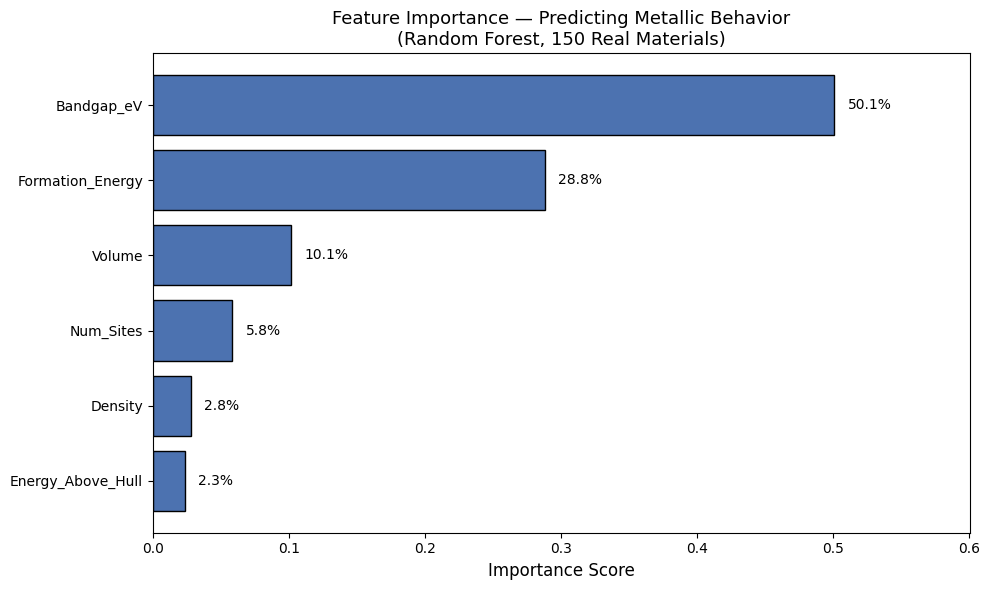

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
import matplotlib.pyplot as plt

importance_sorted = importance.sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(importance_sorted["Feature"], importance_sorted["Importance"],
                 color='#4C72B0', edgecolor='black')

for bar, val in zip(bars, importance_sorted["Importance"]):
    plt.text(val + 0.01, bar.get_y() + bar.get_height()/2,
              f'{val:.1%}', va='center', fontsize=10)

plt.xlabel("Importance Score", fontsize=12)
plt.title("Feature Importance — Predicting Metallic Behavior\n(Random Forest, 150 Real Materials)", fontsize=13)
plt.xlim(0, max(importance_sorted["Importance"]) + 0.1)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

from google.colab import files
files.download("feature_importance.png")